# 10. Бенчмарк сервиса

Latency p50/p95/p99, доля ответов <100 ms, примеры JSON.


In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)


{'n': 800, 'wall_sec': 7.7057630000053905, 'qps': 103.8184018895261, 'mean_ms': 9.61575375, 'p50_ms': 9.682500000000001, 'p95_ms': 16.5397, 'p99_ms': 21.722319999999996, 'max_ms': 31.416, 'under_100ms_share': 1.0}


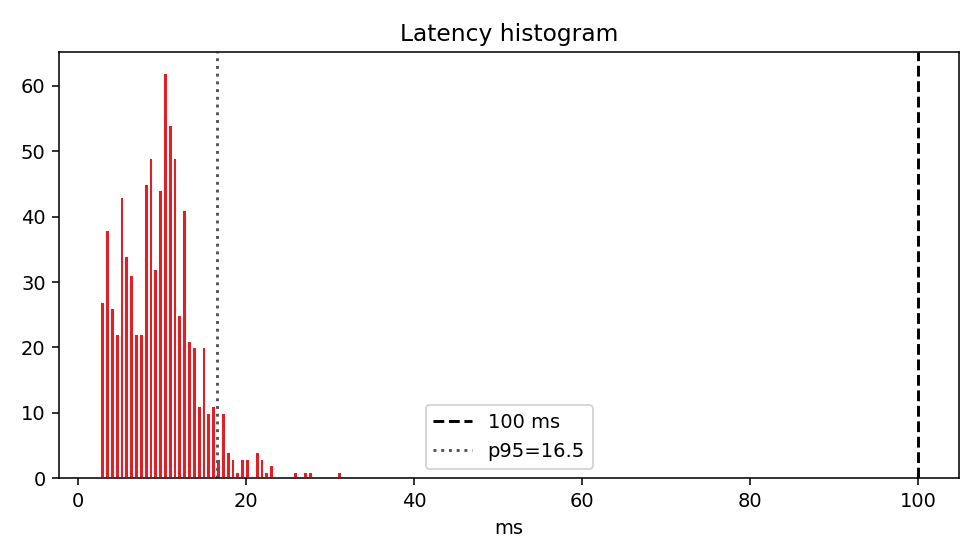

Примеры JSON:
{
  "query": "монитор",
  "entities": [
    {
      "text": "монитор",
      "label": "CATEGORY",
      "span": [
        0,
        7
      ]
    }
  ],
  "brand": "Samsung",
  "category": "монитор",
  "attributes": {},
  "latency_ms": 9.745
}
---
{
  "query": "Электрочайник",
  "entities": [
    {
      "text": "Электрочайник",
      "label": "CATEGORY",
      "span": [
        0,
        13
      ]
    }
  ],
  "brand": "Gorenje",
  "category": "электрочайник",
  "attributes": {},
  "latency_ms": 11.611
}
---
{
  "query": "Миксер",
  "entities": [
    {
      "text": "Миксер",
      "label": "CATEGORY",
      "span": [
        0,
        6
      ]
    }
  ],
  "brand": "Redmond",
  "category": "миксер",
  "attributes": {},
  "latency_ms": 12.35
}
---
{
  "query": "Блендер стационарный",
  "entities": [
    {
      "text": "Блендер стационарный",
      "label": "CATEGORY",
      "span": [
        0,
        20
      ]
    }
  ],
  "brand": "Kitfort",
  "category": "блен

In [2]:
import json
import subprocess
from IPython.display import Image, display

subprocess.check_call([
    sys.executable, str(ROOT / 'scripts' / 'benchmark_latency.py'), '--n', '800'
])
bench = json.loads((ROOT / 'artifacts' / 'benchmark.json').read_text(encoding='utf-8'))
print({k: bench[k] for k in bench if k != 'examples'})
display(Image(filename=str(ROOT / 'figures' / '17_latency_histogram.png')))
print('Примеры JSON:')
for ex in bench.get('examples', [])[:5]:
    print(json.dumps(ex, ensure_ascii=False, indent=2))
    print('---')


## Запуск FastAPI

```bash
uvicorn src.service.app:app --host 0.0.0.0 --port 8000
# POST http://localhost:8000/extract  {"query":"iphone 15 256gb черный"}
```
